# 09 — Spatial Join + Integrate Learned Carbon Model

1. Spatial join: assign forest compartment features to 1km grid cells
2. Train GBR on the joined data (if not done in notebook 08)
3. Integrate as a new carbon model option in the simulator
4. Run evolution comparison: flat vs NIR vs learned

In [1]:
import sys
sys.path.insert(0, "../src")

import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

## Step 1: Spatial join — compartments to 1km grid

In [2]:
# Load grid and compartments
grid = gpd.read_file("../data/processed/v1/base_grid.gpkg")
compartments = gpd.read_file("../data/raw/forest_registry/laane_eraldised.gpkg")

print(f"Grid: {len(grid)} cells")
print(f"Compartments: {len(compartments):,}")

# Ensure same CRS
assert grid.crs == compartments.crs == "EPSG:3301"

Grid: 2806 cells
Compartments: 218,133


In [3]:
# Load detailed attributes (from notebook 07)
details = pd.read_parquet("../data/raw/forest_registry/laane_details.parquet")
print(f"Details: {len(details):,} compartments with forestry data")

# Merge details onto compartments (by eraldis_id)
compartments_with_details = compartments.merge(
    details[["eraldis_id", "peapuuliik", "keskmVanus", "boniteediKood",
             "kasvukohaKood", "kuivendatud", "juurdekasv", "korgus",
             "tagavara1Ha"]],
    on="eraldis_id", how="inner"
)
print(f"Compartments with details: {len(compartments_with_details):,}")

Details: 43,627 compartments with forestry data
Compartments with details: 43,627


## Step 2: Overlay — area-weighted features per grid cell

In [4]:
# Spatial overlay: intersect compartments with grid
# This gives us the intersection geometry (partial compartment within each cell)
overlay = gpd.overlay(
    compartments_with_details[["eraldis_id", "geometry", "peapuuliik",
                               "keskmVanus", "boniteediKood", "kasvukohaKood",
                               "kuivendatud", "juurdekasv", "korgus",
                               "tagavara1Ha", "pindala"]],
    grid[["cell_id", "geometry"]],
    how="intersection",
)

# Compute intersection area (for weighting)
overlay["intersect_area_ha"] = overlay.geometry.area / 10000.0
print(f"Overlay pieces: {len(overlay):,}")
print(f"Grid cells with forest data: {overlay['cell_id'].nunique()}")

Overlay pieces: 23,851
Grid cells with forest data: 2290


C:\Users\risto\projects\et-landuse-neuroevolution\.venv\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 11 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [5]:
# Area-weighted aggregation per grid cell
numeric_cols = ["keskmVanus", "juurdekasv", "korgus", "tagavara1Ha"]

# Weighted mean for numeric columns
def weighted_mean(group, col, weight_col="intersect_area_ha"):
    weights = group[weight_col]
    values = group[col]
    mask = values.notna() & weights.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

cell_features = overlay.groupby("cell_id").apply(
    lambda g: pd.Series({
        "forest_area_ha": g["intersect_area_ha"].sum(),
        "n_compartments": len(g),
        "mean_age": weighted_mean(g, "keskmVanus"),
        "mean_increment": weighted_mean(g, "juurdekasv"),
        "mean_height": weighted_mean(g, "korgus"),
        "mean_volume": weighted_mean(g, "tagavara1Ha"),
        "pct_drained": g["kuivendatud"].mean() if "kuivendatud" in g else 0,
        "dominant_species": g.groupby("peapuuliik")["intersect_area_ha"].sum().idxmax()
            if len(g) > 0 and g["peapuuliik"].notna().any() else None,
    })
).reset_index()

print(f"\nGrid cells with forest features: {len(cell_features)}")
print(cell_features.describe())


Grid cells with forest features: 2290
           cell_id  forest_area_ha  n_compartments     mean_age  \
count  2290.000000     2290.000000     2290.000000  2170.000000   
mean   1479.676419       10.117474       10.415284    73.108592   
std     789.304344        7.597891        6.772599    15.550919   
min       5.000000        0.000003        1.000000    23.000000   
25%     834.250000        3.803739        5.000000    63.796517   
50%    1470.500000        8.670643       10.000000    72.864486   
75%    2167.750000       15.055387       15.000000    81.484813   
max    2805.000000       39.422698       43.000000   168.000000   

       mean_increment  mean_height  mean_volume  pct_drained  
count     2049.000000  2289.000000  2094.000000  2290.000000  
mean         4.670449    22.387073   141.663102     0.335363  
std          1.713729     3.756111    60.077991     0.310611  
min          0.000000     0.000000     0.000000     0.000000  
25%          3.593535    20.600000   103.3

In [6]:
# Save the joined features
output_dir = Path("../data/processed/learned_carbon")
output_dir.mkdir(parents=True, exist_ok=True)

cell_features.to_parquet(output_dir / "grid_forest_features.parquet", index=False)
print(f"Saved to {output_dir / 'grid_forest_features.parquet'}")

Saved to ..\data\processed\learned_carbon\grid_forest_features.parquet


## Step 3: Merge with existing v1 grid features

In [7]:
# Load existing features
v1_features = pd.read_parquet("../data/processed/v1/features_v1_derived.parquet")
print(f"V1 features: {len(v1_features)} cells")

# Merge forest features onto v1
merged = v1_features.merge(cell_features, on="cell_id", how="left")

# Fill missing (non-forest cells) with defaults
merged["mean_age"] = merged["mean_age"].fillna(0)
merged["mean_increment"] = merged["mean_increment"].fillna(0)
merged["mean_height"] = merged["mean_height"].fillna(0)
merged["mean_volume"] = merged["mean_volume"].fillna(0)
merged["pct_drained"] = merged["pct_drained"].fillna(0)
merged["forest_area_ha"] = merged["forest_area_ha"].fillna(0)
merged["n_compartments"] = merged["n_compartments"].fillna(0)
merged["dominant_species"] = merged["dominant_species"].fillna("none")

print(f"Merged: {len(merged)} cells")
print(f"Cells with forest data: {(merged['forest_area_ha'] > 0).sum()}")

# Save
merged.to_parquet(output_dir / "features_with_forest.parquet", index=False)
print(f"Saved enriched features to {output_dir / 'features_with_forest.parquet'}")

V1 features: 2806 cells
Merged: 2806 cells
Cells with forest data: 2290
Saved enriched features to ..\data\processed\learned_carbon\features_with_forest.parquet


## Step 4: Visualize

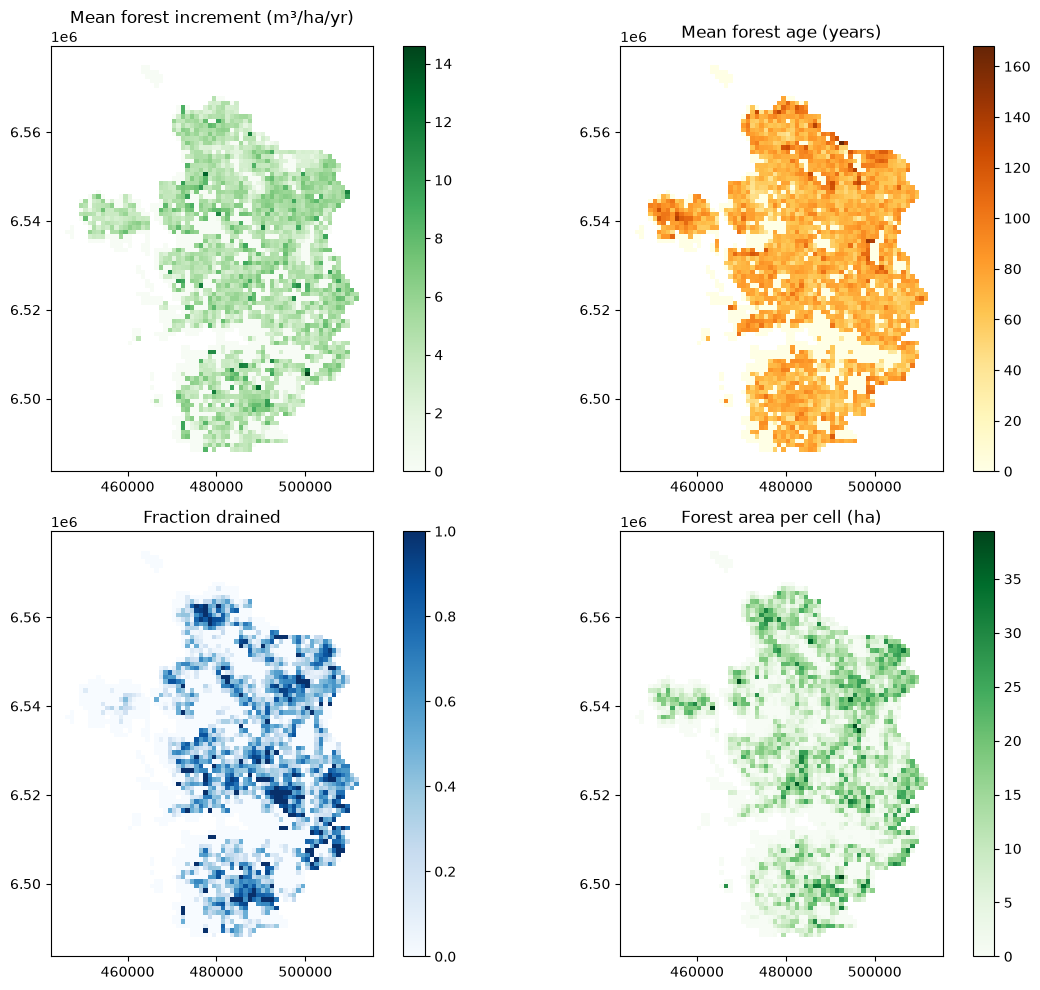

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
merged_geo = grid.merge(merged[["cell_id", "mean_increment"]], on="cell_id")
merged_geo.plot(column="mean_increment", ax=ax, legend=True, cmap="Greens",
                missing_kwds={"color": "lightgrey"})
ax.set_title("Mean forest increment (m³/ha/yr)")

ax = axes[0, 1]
merged_geo2 = grid.merge(merged[["cell_id", "mean_age"]], on="cell_id")
merged_geo2.plot(column="mean_age", ax=ax, legend=True, cmap="YlOrBr",
                 missing_kwds={"color": "lightgrey"})
ax.set_title("Mean forest age (years)")

ax = axes[1, 0]
merged_geo3 = grid.merge(merged[["cell_id", "pct_drained"]], on="cell_id")
merged_geo3.plot(column="pct_drained", ax=ax, legend=True, cmap="Blues",
                 missing_kwds={"color": "lightgrey"})
ax.set_title("Fraction drained")

ax = axes[1, 1]
merged_geo4 = grid.merge(merged[["cell_id", "forest_area_ha"]], on="cell_id")
merged_geo4.plot(column="forest_area_ha", ax=ax, legend=True, cmap="Greens",
                 missing_kwds={"color": "lightgrey"})
ax.set_title("Forest area per cell (ha)")

plt.tight_layout()
plt.show()

## Step 5: Create the learned carbon scorer

Uses the trained GBR model to score carbon for each cell based on its
forest features and the proposed land-use transition.

In [9]:
# Load or train the model (from notebook 08)
from carbon_dataset.forest_carbon_model import load_or_train_model

model = load_or_train_model(training_data=overlay)

Loaded model from C:\Users\risto\projects\et-landuse-neuroevolution\data\processed\learned_carbon\forest_carbon_gbr.joblib


## Step 6: Run evolution with the learned model

Compare three carbon models:
- flat (existing)
- nir (NIR-calibrated)
- learned (GBR from real forest data)

In [10]:
from estonia_landuse.optimizer.trainer import train as run_evolution
from estonia_landuse.simulator.config import default_config
from estonia_landuse.simulator.simulator import summarize_policy

# Load enriched features
features_df = pd.read_parquet(output_dir / "features_with_forest.parquet")
if "peat_overlap_pct" not in features_df.columns:
    features_df["peat_overlap_pct"] = features_df.get("pct_drained", 0)

# Merge Rohemeeter biodiversity scores (same as 03.2)
CARBON_DIR = Path("../data/processed/carbon_v1_5")
rohemeeter_path = CARBON_DIR / "rohemeeter_scores.parquet"
if rohemeeter_path.exists():
    rohemeeter = pd.read_parquet(rohemeeter_path)
    features_df = features_df.merge(
        rohemeeter[["cell_id", "rohemeeter_mean"]], on="cell_id", how="left"
    )
    features_df["rohemeeter_norm"] = features_df["rohemeeter_mean"].fillna(50) / 100.0
    print(f"Rohemeeter merged: mean={features_df['rohemeeter_norm'].mean():.3f}")
else:
    features_df["rohemeeter_norm"] = 0.5
    print("WARNING: Rohemeeter scores not found, using fallback 0.5")

# Feature columns for prescriptor (matches 03.2)
FEATURE_COLUMNS = [
    "urban_pct", "agriculture_pct", "grassland_pct", "forest_pct",
    "wetland_pct", "water_pct", "naturalness_score", "carbon_score",
    "protected_overlap_pct", "wetland_suitability", "biodiversity_proxy",
    "opportunity_cost_proxy", "rohemeeter_norm",
]
FEATURE_COLUMNS = [c for c in FEATURE_COLUMNS if c in features_df.columns]
print(f"Using {len(FEATURE_COLUMNS)} features for prescriptor")

# Quick evolution parameters
POP_SIZE = 100
N_GENERATIONS = 130

Rohemeeter merged: mean=0.646
Using 13 features for prescriptor


In [11]:
import time

results = {}
for model_name in ["flat", "nir", "learned"]:
    config = default_config()
    config["carbon_model"] = model_name
    
    print(f"\n{'='*50}")
    print(f"Running evolution: carbon_model = {model_name}")
    t0 = time.time()
    
    pop = run_evolution(
        context=features_df,
        feature_columns=FEATURE_COLUMNS,
        pop_size=POP_SIZE,
        n_generations=N_GENERATIONS,
        config=config,
        verbose=True,
    )
    
    dt = time.time() - t0
    front0 = [p for p in pop if p.rank == 0]
    results[model_name] = {"pop": pop, "front0": front0, "time": dt}
    print(f"Done in {dt:.1f}s, front-0: {len(front0)}")


Running evolution: carbon_model = flat


C:\Users\risto\projects\et-landuse-neuroevolution\notebooks\../src\estonia_landuse\optimizer\seeds.py:42: RuntimeWarning: invalid value encountered in divide
  current_norm = np.where(current_sum > 0, current / current_sum, 0.25)


Created 4 seed prescriptors
Gen  10 | Front-0: 100 | Avg: bio=-0.0237 carbon=0.0569 cost=4.6481 change=24.7%
Gen  20 | Front-0: 100 | Avg: bio=-0.0349 carbon=0.0815 cost=6.9931 change=28.1%
Gen  30 | Front-0: 100 | Avg: bio=-0.0427 carbon=0.0963 cost=8.0623 change=29.6%
Gen  40 | Front-0: 100 | Avg: bio=-0.0595 carbon=0.1110 cost=8.0163 change=32.8%
Gen  50 | Front-0: 100 | Avg: bio=-0.0617 carbon=0.1169 cost=7.7141 change=33.6%
Gen  60 | Front-0: 100 | Avg: bio=-0.0582 carbon=0.1161 cost=8.5746 change=33.1%
Gen  70 | Front-0: 100 | Avg: bio=-0.0630 carbon=0.1201 cost=9.6304 change=33.4%
Gen  80 | Front-0: 100 | Avg: bio=-0.0665 carbon=0.1238 cost=9.2930 change=33.9%
Gen  90 | Front-0: 100 | Avg: bio=-0.0636 carbon=0.1266 cost=10.0474 change=34.2%
Gen 100 | Front-0: 100 | Avg: bio=-0.0641 carbon=0.1279 cost=10.8065 change=34.9%
Gen 110 | Front-0: 100 | Avg: bio=-0.0602 carbon=0.1220 cost=10.2657 change=33.4%
Gen 120 | Front-0: 100 | Avg: bio=-0.0624 carbon=0.1231 cost=9.8365 change=33.

C:\Users\risto\projects\et-landuse-neuroevolution\notebooks\../src\estonia_landuse\optimizer\seeds.py:42: RuntimeWarning: invalid value encountered in divide
  current_norm = np.where(current_sum > 0, current / current_sum, 0.25)


Created 4 seed prescriptors
Gen  10 | Front-0:  40 | Avg: bio=0.0026 carbon=0.0039 cost=3.0196 change=18.7%
Gen  20 | Front-0: 100 | Avg: bio=0.0162 carbon=0.0246 cost=3.3182 change=16.2%
Gen  30 | Front-0: 100 | Avg: bio=0.0270 carbon=0.0401 cost=4.7947 change=16.0%
Gen  40 | Front-0: 100 | Avg: bio=0.0291 carbon=0.0437 cost=5.5099 change=15.8%
Gen  50 | Front-0: 100 | Avg: bio=0.0284 carbon=0.0414 cost=5.5502 change=15.5%
Gen  60 | Front-0: 100 | Avg: bio=0.0311 carbon=0.0449 cost=6.3197 change=15.4%
Gen  70 | Front-0: 100 | Avg: bio=0.0328 carbon=0.0478 cost=6.6187 change=15.4%
Gen  80 | Front-0: 100 | Avg: bio=0.0329 carbon=0.0466 cost=6.9708 change=15.3%
Gen  90 | Front-0: 100 | Avg: bio=0.0323 carbon=0.0455 cost=6.6058 change=15.3%
Gen 100 | Front-0: 100 | Avg: bio=0.0315 carbon=0.0444 cost=6.3383 change=14.7%
Gen 110 | Front-0: 100 | Avg: bio=0.0292 carbon=0.0389 cost=6.0887 change=14.4%
Gen 120 | Front-0: 100 | Avg: bio=0.0315 carbon=0.0429 cost=6.4916 change=14.3%
Gen 130 | Fr

C:\Users\risto\projects\et-landuse-neuroevolution\notebooks\../src\estonia_landuse\optimizer\seeds.py:42: RuntimeWarning: invalid value encountered in divide
  current_norm = np.where(current_sum > 0, current / current_sum, 0.25)


Created 4 seed prescriptors
Gen  10 | Front-0:  23 | Avg: bio=0.0044 carbon=0.0131 cost=2.8271 change=20.2%
Gen  20 | Front-0:  92 | Avg: bio=0.0297 carbon=0.0496 cost=5.2322 change=18.9%
Gen  30 | Front-0: 100 | Avg: bio=0.0282 carbon=0.0516 cost=4.6657 change=17.6%
Gen  40 | Front-0: 100 | Avg: bio=0.0282 carbon=0.0497 cost=5.4725 change=17.3%
Gen  50 | Front-0: 100 | Avg: bio=0.0297 carbon=0.0511 cost=5.9466 change=16.9%
Gen  60 | Front-0: 100 | Avg: bio=0.0308 carbon=0.0510 cost=6.3208 change=16.4%
Gen  70 | Front-0: 100 | Avg: bio=0.0317 carbon=0.0505 cost=6.2342 change=16.1%
Gen  80 | Front-0: 100 | Avg: bio=0.0343 carbon=0.0513 cost=6.7210 change=15.7%
Gen  90 | Front-0: 100 | Avg: bio=0.0326 carbon=0.0481 cost=6.8276 change=15.1%
Gen 100 | Front-0: 100 | Avg: bio=0.0302 carbon=0.0452 cost=6.6360 change=14.8%
Gen 110 | Front-0: 100 | Avg: bio=0.0326 carbon=0.0475 cost=7.4062 change=15.1%
Gen 120 | Front-0: 100 | Avg: bio=0.0305 carbon=0.0458 cost=7.3485 change=14.8%
Gen 130 | Fr

## Step 7: Evaluate all policies with all models

In [12]:
def evaluate_front(population, context, config, label):
    """Evaluate Pareto front with a given config."""
    features = context[FEATURE_COLUMNS].values.astype(np.float32)
    feat_mean = features.mean(axis=0)
    feat_std = features.std(axis=0)
    feat_std[feat_std == 0] = 1.0
    features_norm = (features - feat_mean) / feat_std

    rows = []
    for p in population:
        if p.rank != 0:
            continue
        targets = p.prescribe(features_norm)
        summary = summarize_policy(context, targets, config)
        summary["label"] = label
        rows.append(summary)
    return pd.DataFrame(rows)

# Cross-evaluate
config_flat = default_config(); config_flat["carbon_model"] = "flat"
config_nir = default_config(); config_nir["carbon_model"] = "nir"
config_learned = default_config(); config_learned["carbon_model"] = "learned"

all_evals = []
for model_name, data in results.items():
    for eval_name, eval_config in [("flat", config_flat), ("nir", config_nir), ("learned", config_learned)]:
        evals = evaluate_front(
            data["pop"], features_df, eval_config,
            f"{model_name}_policy+{eval_name}_eval"
        )
        all_evals.append(evals)

comparison = pd.concat(all_evals, ignore_index=True)
comparison.to_parquet(output_dir / "evolution_comparison.parquet", index=False)
print("\nCross-evaluation summary:")
print(comparison.groupby("label")[["biodiversity_gain", "carbon_gain", "cost", "changed_pct"]].mean().to_string())


Cross-evaluation summary:
                             biodiversity_gain  carbon_gain      cost  changed_pct
label                                                                             
flat_policy+flat_eval                -0.054232     0.116326  9.201697     0.323027
flat_policy+learned_eval             -0.054232    -0.031048  9.201697     0.323027
flat_policy+nir_eval                 -0.054232     0.021032  9.201697     0.323027
learned_policy+flat_eval              0.034409     0.047613  7.980296     0.154853
learned_policy+learned_eval           0.034409     0.051287  7.980296     0.154853
learned_policy+nir_eval               0.034409     0.051672  7.980296     0.154853
nir_policy+flat_eval                  0.034016     0.046818  6.887689     0.147069
nir_policy+learned_eval               0.034016     0.045908  6.887689     0.147069
nir_policy+nir_eval                   0.034016     0.048441  6.887689     0.147069


## Step 8: All Pareto Fronts (4-panel)

In [13]:
# Get pareto DataFrames for both models (evaluated by their own model)
def get_pareto_df(population, context, config):
    features = context[FEATURE_COLUMNS].values.astype(np.float32)
    feat_mean = features.mean(axis=0)
    feat_std = features.std(axis=0)
    feat_std[feat_std == 0] = 1.0
    feat_norm = (features - feat_mean) / feat_std
    rows = []
    for i, p in enumerate(population):
        if p.rank != 0:
            continue
        targets = p.prescribe(feat_norm)
        s = summarize_policy(context, targets, config)
        s["id"] = i
        rows.append(s)
    return pd.DataFrame(rows), feat_norm

pareto_flat, feat_norm = get_pareto_df(results["flat"]["pop"], features_df, config_flat)
pareto_nir, _ = get_pareto_df(results["nir"]["pop"], features_df, config_nir)
pareto_learned, _ = get_pareto_df(results["learned"]["pop"], features_df, config_learned)
print(f"Flat front-0: {len(pareto_flat)}, NIR front-0: {len(pareto_nir)}, Learned front-0: {len(pareto_learned)}")

Flat front-0: 100, NIR front-0: 100, Learned front-0: 100


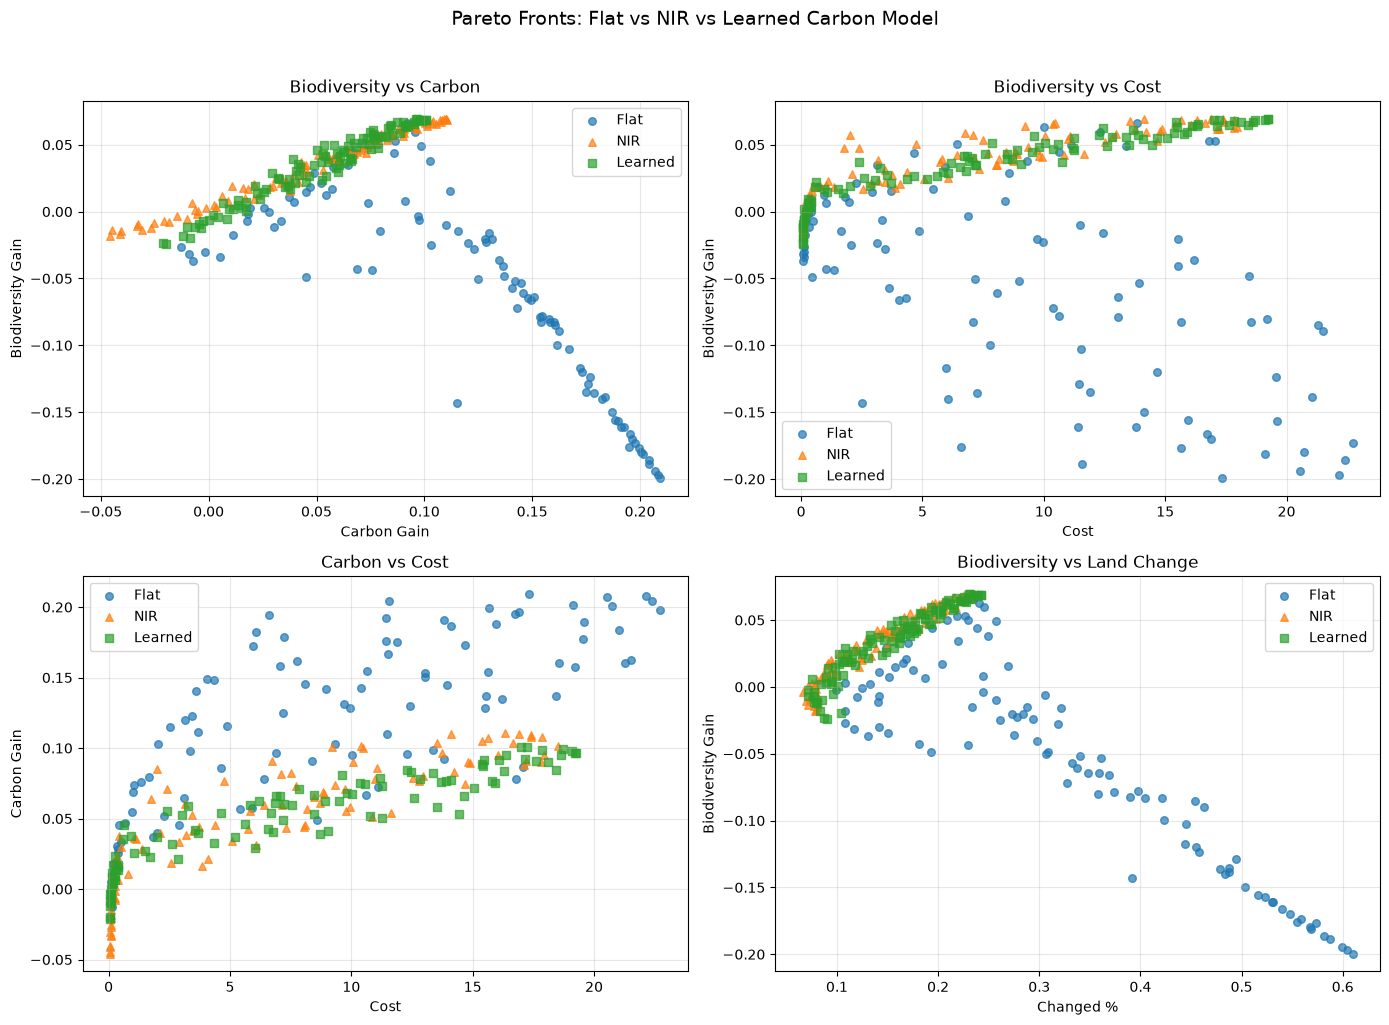

In [14]:
# 4-panel Pareto front comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

all_paretos = [("Flat", pareto_flat, "tab:blue", "o"),
               ("NIR", pareto_nir, "tab:orange", "^"),
               ("Learned", pareto_learned, "tab:green", "s")]

ax = axes[0, 0]
for name, pdf, color, marker in all_paretos:
    ax.scatter(pdf["carbon_gain"], pdf["biodiversity_gain"],
               alpha=0.7, s=30, label=name, color=color, marker=marker)
ax.set_xlabel("Carbon Gain"); ax.set_ylabel("Biodiversity Gain")
ax.set_title("Biodiversity vs Carbon"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for name, pdf, color, marker in all_paretos:
    ax.scatter(pdf["cost"], pdf["biodiversity_gain"],
               alpha=0.7, s=30, label=name, color=color, marker=marker)
ax.set_xlabel("Cost"); ax.set_ylabel("Biodiversity Gain")
ax.set_title("Biodiversity vs Cost"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
for name, pdf, color, marker in all_paretos:
    ax.scatter(pdf["cost"], pdf["carbon_gain"],
               alpha=0.7, s=30, label=name, color=color, marker=marker)
ax.set_xlabel("Cost"); ax.set_ylabel("Carbon Gain")
ax.set_title("Carbon vs Cost"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
for name, pdf, color, marker in all_paretos:
    ax.scatter(pdf["changed_pct"], pdf["biodiversity_gain"],
               alpha=0.7, s=30, label=name, color=color, marker=marker)
ax.set_xlabel("Changed %"); ax.set_ylabel("Biodiversity Gain")
ax.set_title("Biodiversity vs Land Change"); ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle("Pareto Fronts: Flat vs NIR vs Learned Carbon Model", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 9: Total Gains — Best Policy Bar Chart

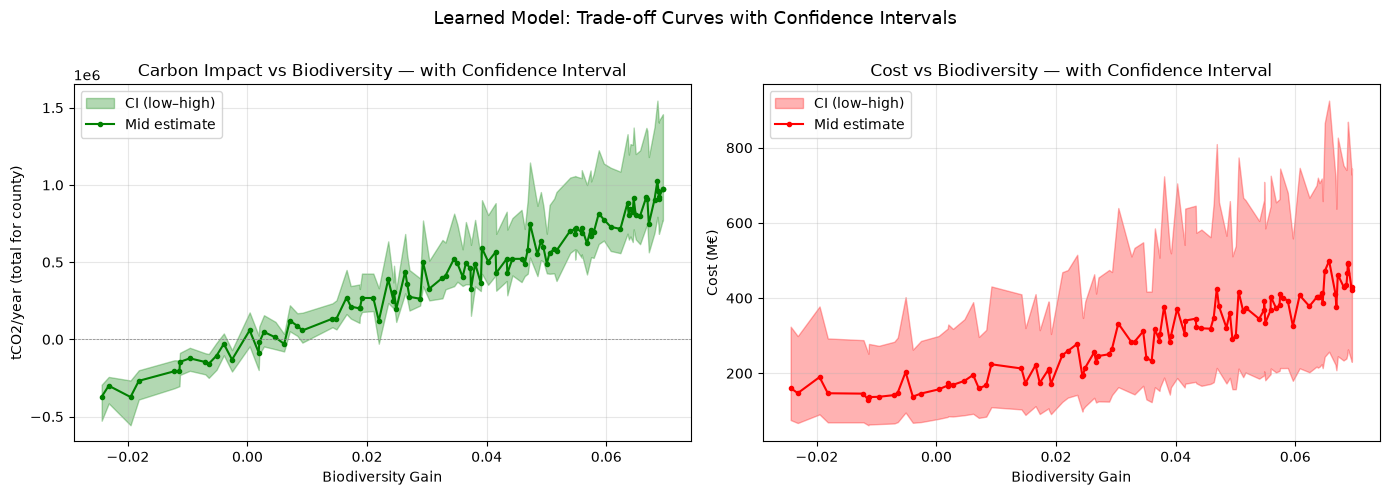

In [15]:
# Pick best biodiversity policy from each model
best_flat_idx = pareto_flat["biodiversity_gain"].idxmax()
best_nir_idx = pareto_nir["biodiversity_gain"].idxmax()
best_learned_idx = pareto_learned["biodiversity_gain"].idxmax()

flat_front0 = [p for p in results["flat"]["pop"] if p.rank == 0]
nir_front0 = [p for p in results["nir"]["pop"] if p.rank == 0]
learned_front0 = [p for p in results["learned"]["pop"] if p.rank == 0]

# Use learned model's best policy for map/CI analysis
best_policy = learned_front0[best_learned_idx]

# Compute tCO2 with confidence interval for all NIR front policies
from estonia_landuse.simulator.carbon_tonnes import estimate_carbon_tonnes_ci
from estonia_landuse.simulator.cost_eur import estimate_cost_eur_ci

results_ci = []
for i, p in enumerate(learned_front0):
    targets = p.prescribe(feat_norm)
    carbon_ci = estimate_carbon_tonnes_ci(features_df, targets)
    cost_ci = estimate_cost_eur_ci(features_df, targets)
    results_ci.append({
        "id": i,
        "tco2_low": carbon_ci["low"]["total_tco2_per_year"],
        "tco2_mid": carbon_ci["mid"]["total_tco2_per_year"],
        "tco2_high": carbon_ci["high"]["total_tco2_per_year"],
        "cost_low": cost_ci["low"]["total_cost_eur"] / 1e6,
        "cost_mid": cost_ci["mid"]["total_cost_eur"] / 1e6,
        "cost_high": cost_ci["high"]["total_cost_eur"] / 1e6,
        "bio_gain": pareto_learned.loc[i, "biodiversity_gain"],
    })

ci_df = pd.DataFrame(results_ci).sort_values("bio_gain")

# Plot tCO2 vs Biodiversity with CI band
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].fill_between(ci_df["bio_gain"], ci_df["tco2_low"], ci_df["tco2_high"],
                     alpha=0.3, color="green", label="CI (low–high)")
axes[0].plot(ci_df["bio_gain"], ci_df["tco2_mid"], "g-o", ms=3, label="Mid estimate")
axes[0].set_xlabel("Biodiversity Gain")
axes[0].set_ylabel("tCO2/year (total for county)")
axes[0].set_title("Carbon Impact vs Biodiversity — with Confidence Interval")
axes[0].legend()
axes[0].axhline(0, color="gray", ls="--", lw=0.5)
axes[0].grid(True, alpha=0.3)

# Plot cost with CI
axes[1].fill_between(ci_df["bio_gain"], ci_df["cost_low"], ci_df["cost_high"],
                     alpha=0.3, color="red", label="CI (low–high)")
axes[1].plot(ci_df["bio_gain"], ci_df["cost_mid"], "r-o", ms=3, label="Mid estimate")
axes[1].set_xlabel("Biodiversity Gain")
axes[1].set_ylabel("Cost (M€)")
axes[1].set_title("Cost vs Biodiversity — with Confidence Interval")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Learned Model: Trade-off Curves with Confidence Intervals", fontsize=13)
plt.tight_layout()
plt.show()

## Step 10: Map — Best Learned Policy (Change Intensity)

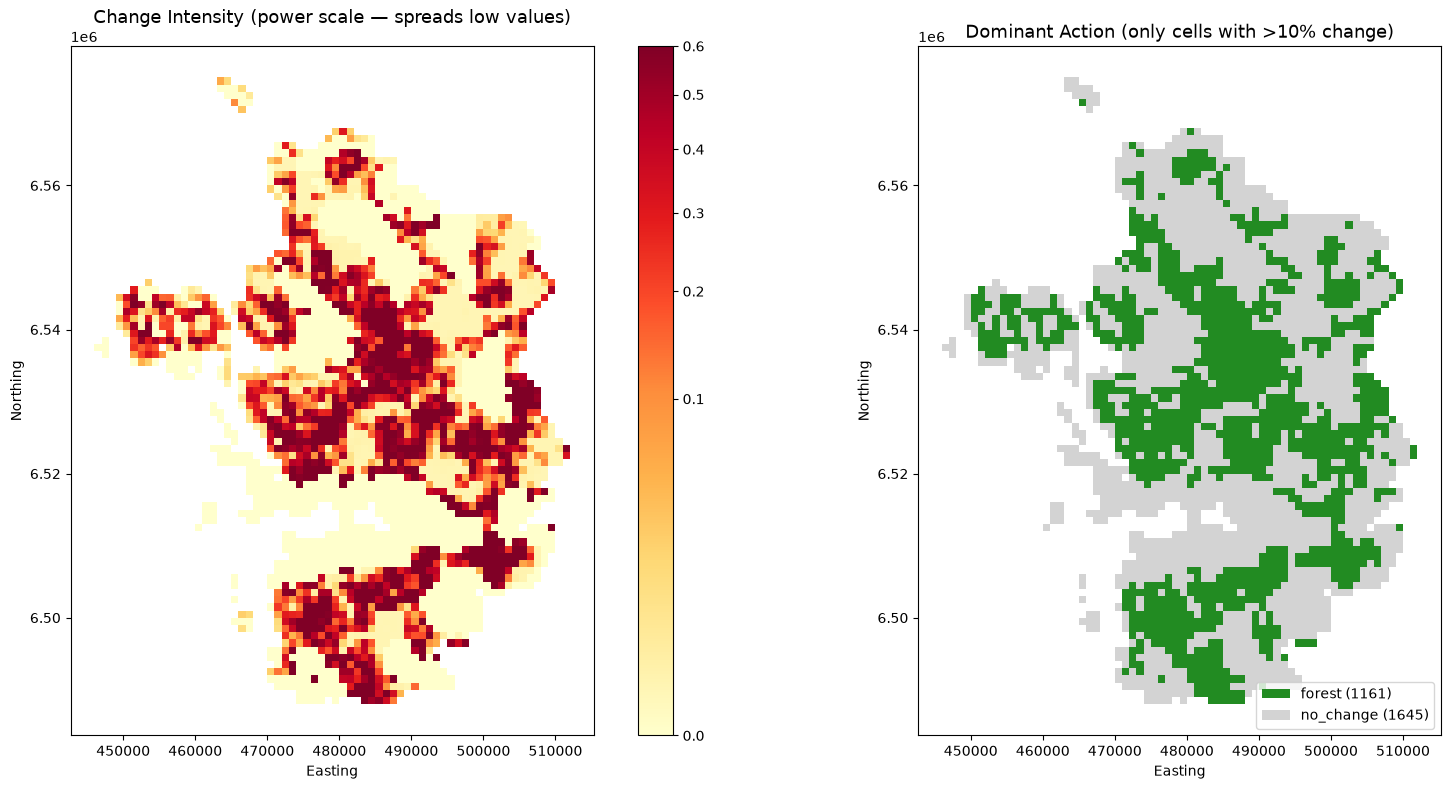

In [16]:
# Get best learned policy targets
best_targets = best_policy.prescribe(feat_norm)

# Compute delta and change intensity
groups = ["forest", "wetland", "agriculture", "grassland"]
current = np.column_stack([features_df[f"{g}_pct"].values for g in groups])

urban = features_df["urban_pct"].values
water = features_df["water_pct"].values
available = np.clip(1.0 - urban - water, 0, 1)
tgt_sum = best_targets.sum(axis=1, keepdims=True)
tgt_sum = np.where(tgt_sum > 0, tgt_sum, 1.0)
targets_norm = best_targets / tgt_sum * available[:, None]

delta = targets_norm - current

# Zero out changes in protected cells (prescriptor may still propose them,
# but they would be blocked by the simulator — don't show on map)
protected_threshold = 0.15
is_protected = features_df["protected_overlap_pct"].values > protected_threshold
delta[is_protected] = 0
# Also reset targets to current for protected cells (so "Optimal" map = Current in those areas)
targets_norm[is_protected] = current[is_protected]

# Prepare protected area overlay for all maps
protected_cells = grid[["cell_id", "geometry"]].copy()
protected_cells["is_prot"] = is_protected
protected_overlay = protected_cells[protected_cells["is_prot"]]

# Change intensity: fraction of cell land that changes use (0 = nothing, 1 = full conversion)
change_intensity = np.abs(delta).sum(axis=1) / 2.0

# Dominant action (for the second subplot)
dominant_action = np.array(groups)[delta.argmax(axis=1)]
dominant_action[change_intensity < 0.05] = "no_change"

features_df["action"] = dominant_action
features_df["change_intensity"] = change_intensity

# --- Two-panel map ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Change intensity (continuous, power-law scale for better contrast)
from matplotlib.colors import PowerNorm
map_df = grid.merge(features_df[["cell_id", "change_intensity"]], on="cell_id")
map_df.plot(column="change_intensity", ax=axes[0], legend=True, cmap="YlOrRd",
            norm=PowerNorm(gamma=0.4, vmin=0, vmax=0.6),
            missing_kwds={"color": "lightgrey"})
axes[0].set_title("Change Intensity (power scale — spreads low values)", fontsize=13)
axes[0].set_xlabel("Easting"); axes[0].set_ylabel("Northing")

# Right: Dominant action (categorical) but only where change > 10%
map_df2 = grid.merge(features_df[["cell_id", "action", "change_intensity"]], on="cell_id")
# Re-classify with higher threshold for visibility
map_df2.loc[map_df2["change_intensity"] < 0.10, "action"] = "no_change"

color_map = {
    "forest": "#228B22", "wetland": "#4682B4",
    "agriculture": "#DAA520", "grassland": "#90EE90", "no_change": "#D3D3D3",
}
for action, color in color_map.items():
    subset = map_df2[map_df2["action"] == action]
    if len(subset) > 0:
        subset.plot(ax=axes[1], color=color, label=f"{action} ({len(subset)})")

axes[1].legend(loc="lower right", fontsize=10)
axes[1].set_title("Dominant Action (only cells with >10% change)", fontsize=13)
axes[1].set_xlabel("Easting"); axes[1].set_ylabel("Northing")

plt.tight_layout()
plt.show()

In [17]:
# Action distribution (>10% threshold)
print("Action distribution (>10% change threshold):")
action_counts = map_df2["action"].value_counts()
for action, count in action_counts.items():
    print(f"  {action:15s}: {count:>5d} cells ({count/len(features_df)*100:.1f}%)")

print(f"\nChange intensity stats:")
print(f"  Mean: {change_intensity.mean():.1%}")
print(f"  Median: {np.median(change_intensity):.1%}")
print(f"  Cells with >10% change: {(change_intensity > 0.10).sum()} ({(change_intensity > 0.10).mean()*100:.0f}%)")
print(f"  Cells with >25% change: {(change_intensity > 0.25).sum()} ({(change_intensity > 0.25).mean()*100:.0f}%)")

Action distribution (>10% change threshold):
  no_change      :  1645 cells (58.6%)
  forest         :  1161 cells (41.4%)

Change intensity stats:
  Mean: 21.2%
  Median: 0.9%
  Cells with >10% change: 1161 (41%)
  Cells with >25% change: 907 (32%)


## Step 11: Current vs Optimal — Per Land Use Type

County border loaded: Lääne (1 polygon(s))


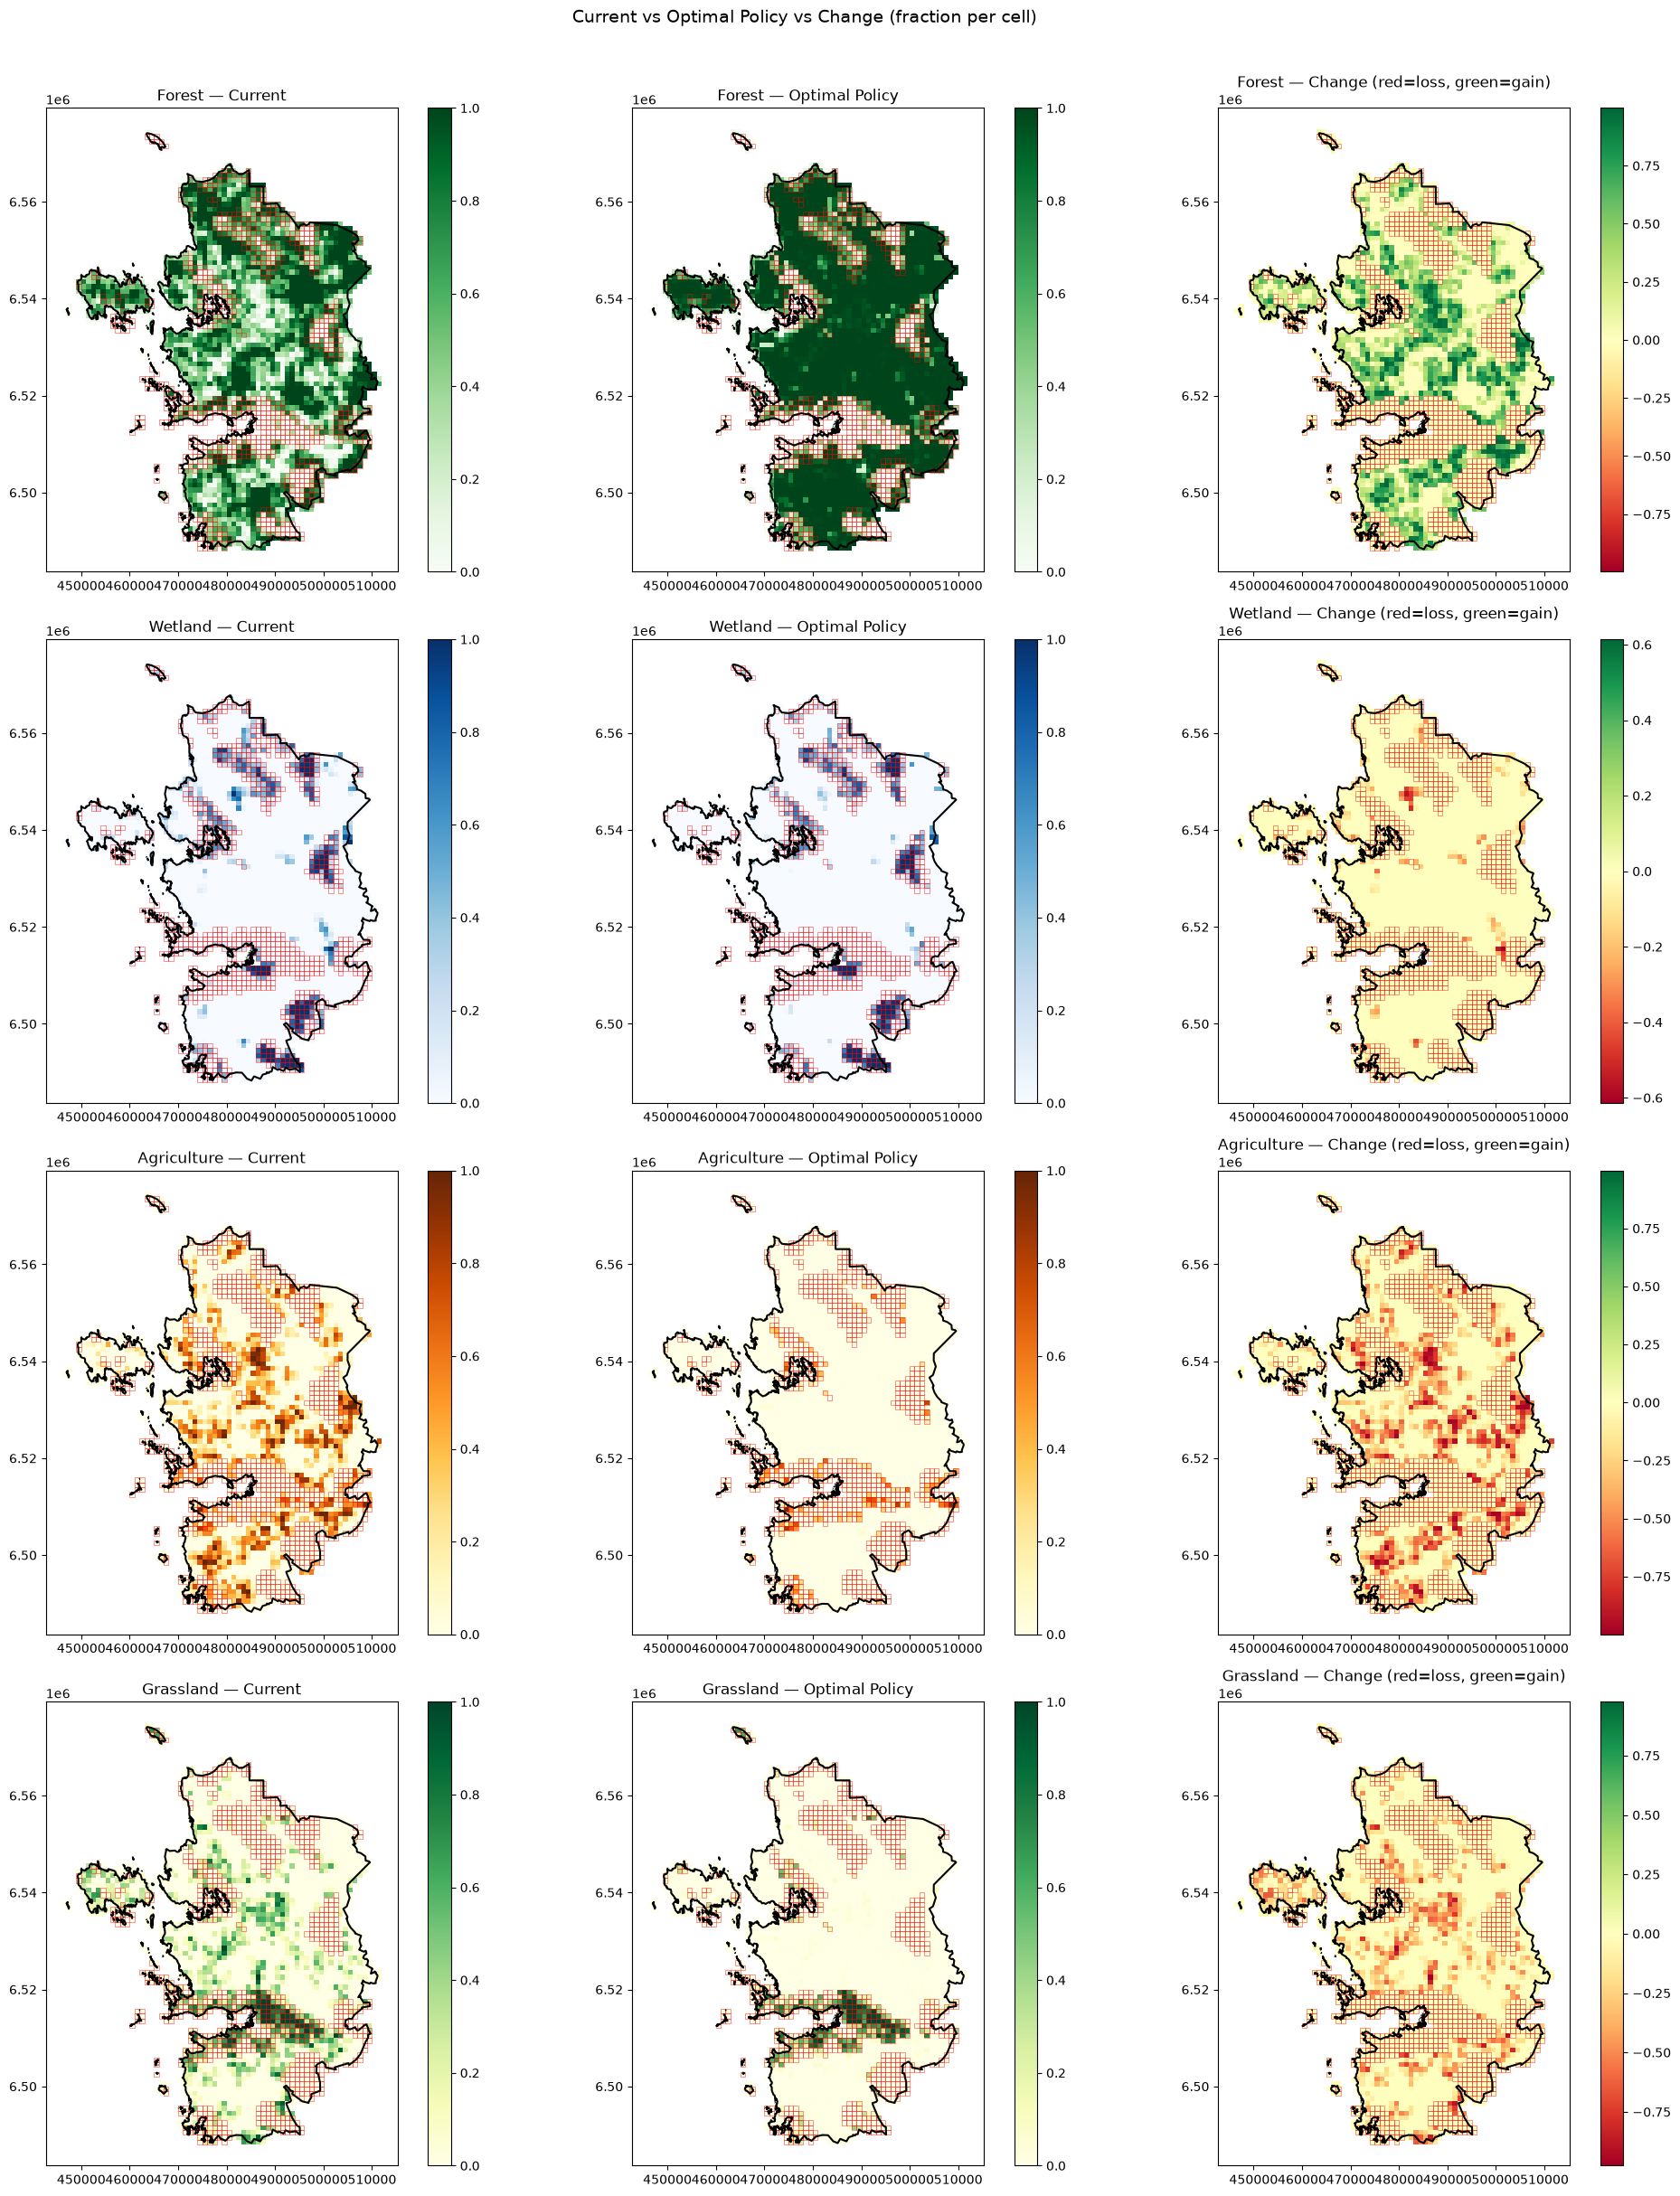

In [18]:
# Side-by-side maps: current fraction vs target fraction for each land use type
# Load county boundary for overlay
from estonia_landuse.data.constants import GADM_COUNTIES_URL, COUNTY_NAME

try:
    all_counties = gpd.read_file(GADM_COUNTIES_URL)
    county_border = all_counties[all_counties["NAME_1"] == COUNTY_NAME]
    if county_border.crs != "EPSG:3301":
        county_border = county_border.to_crs("EPSG:3301")
    has_border = len(county_border) > 0
    if has_border:
        print(f"County border loaded: {COUNTY_NAME} ({len(county_border)} polygon(s))")
except Exception as e:
    has_border = False
    print(f"Could not load county border: {e}")

fig, axes = plt.subplots(4, 3, figsize=(20, 24))

groups_display = ["forest", "wetland", "agriculture", "grassland"]
cmaps = ["Greens", "Blues", "YlOrBr", "YlGn"]

for i, (group, cmap) in enumerate(zip(groups_display, cmaps)):
    # Current
    map_current = grid.merge(
        pd.DataFrame({"cell_id": features_df["cell_id"], "value": current[:, i]}),
        on="cell_id"
    )
    map_current.plot(column="value", ax=axes[i, 0], legend=True, cmap=cmap,
                     vmin=0, vmax=1, missing_kwds={"color": "lightgrey"})
    axes[i, 0].set_title(f"{group.title()} — Current", fontsize=12)
    axes[i, 0].set_xlabel(""); axes[i, 0].set_ylabel("")

    # Target (optimal policy)
    map_target = grid.merge(
        pd.DataFrame({"cell_id": features_df["cell_id"], "value": targets_norm[:, i]}),
        on="cell_id"
    )
    map_target.plot(column="value", ax=axes[i, 1], legend=True, cmap=cmap,
                    vmin=0, vmax=1, missing_kwds={"color": "lightgrey"})
    axes[i, 1].set_title(f"{group.title()} — Optimal Policy", fontsize=12)
    axes[i, 1].set_xlabel(""); axes[i, 1].set_ylabel("")

    # Delta (diverging: red=decrease, white=no change, green/blue=increase)
    delta_col = delta[:, i]
    map_delta = grid.merge(
        pd.DataFrame({"cell_id": features_df["cell_id"], "value": delta_col}),
        on="cell_id"
    )
    vmax_delta = max(abs(delta_col.min()), abs(delta_col.max()), 0.3)
    map_delta.plot(column="value", ax=axes[i, 2], legend=True, cmap="RdYlGn",
                   vmin=-vmax_delta, vmax=vmax_delta,
                   missing_kwds={"color": "lightgrey"})
    axes[i, 2].set_title(f"{group.title()} — Change (red=loss, green=gain)", fontsize=12)
    axes[i, 2].set_xlabel(""); axes[i, 2].set_ylabel("")

    # Add county border and protected areas to all panels
    if has_border:
        for j in range(3):
            county_border.boundary.plot(ax=axes[i, j], color="black", linewidth=1.5)
            protected_overlay.plot(ax=axes[i, j], facecolor="none",
                                   edgecolor="red", linewidth=0.5, alpha=0.6)

plt.suptitle("Current vs Optimal Policy vs Change (fraction per cell)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Step 12: Protected Areas Map

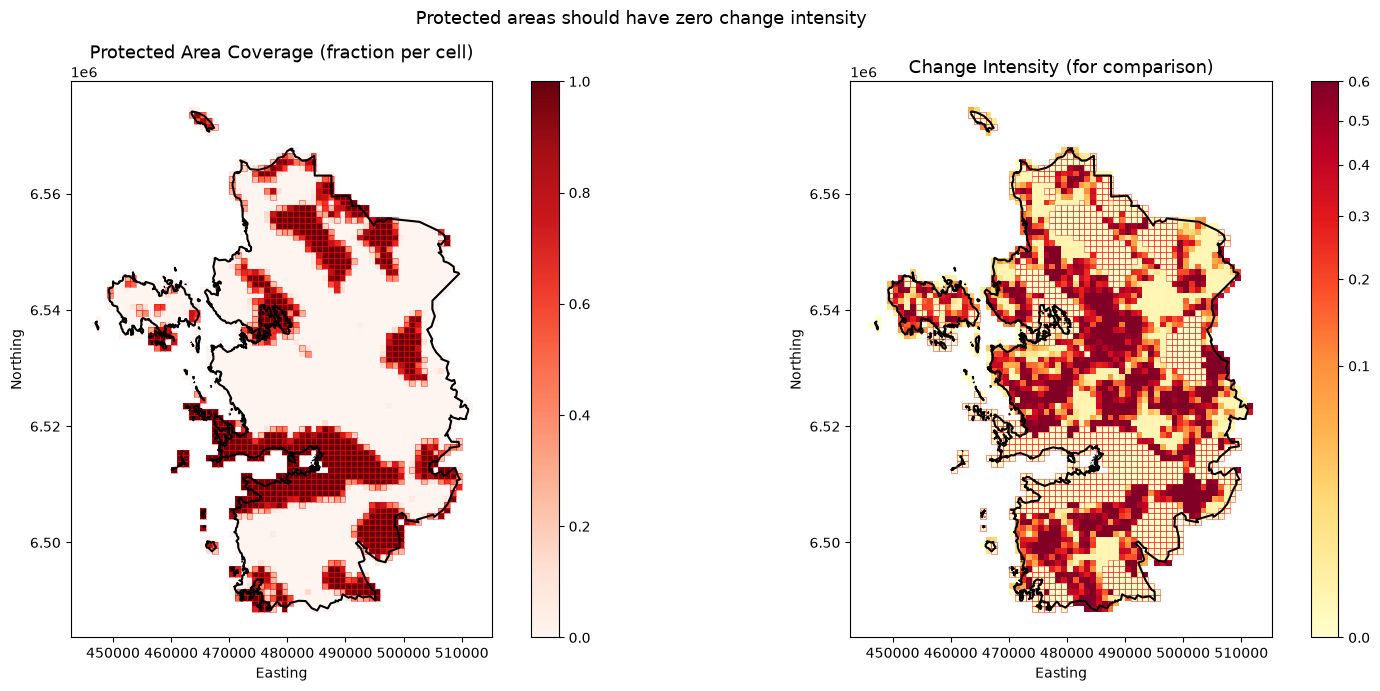

Protected area stats:
  Cells with any protection (>0): 1202 (43%)
  Cells fully protected (>0.8): 644 (23%)
  Cells partially protected (0.5-0.8): 144


In [19]:
# Show protected_overlap_pct alongside the change map
# Ensure protected_overlap_pct is available
if "protected_overlap_pct" not in features_df.columns:
    v1_prot = pd.read_parquet("../data/processed/v1/features_v1_derived.parquet",
                              columns=["cell_id", "protected_overlap_pct"])
    features_df = features_df.merge(v1_prot, on="cell_id", how="left")
    features_df["protected_overlap_pct"] = features_df["protected_overlap_pct"].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Protected areas coverage
prot_values = features_df["protected_overlap_pct"].values
map_prot = grid[["cell_id", "geometry"]].copy()
map_prot["protected_pct"] = prot_values
map_prot.plot(column="protected_pct", ax=axes[0], legend=True, cmap="Reds",
              vmin=0, vmax=1, missing_kwds={"color": "lightgrey"})
if has_border:
    county_border.boundary.plot(ax=axes[0], color="black", linewidth=1.5)
    protected_overlay.plot(ax=axes[0], facecolor="none", edgecolor="red", linewidth=0.5, alpha=0.6)
axes[0].set_title("Protected Area Coverage (fraction per cell)", fontsize=13)
axes[0].set_xlabel("Easting"); axes[0].set_ylabel("Northing")

# Change intensity for comparison
map_change = grid[["cell_id", "geometry"]].copy()
map_change["change_intensity"] = features_df["change_intensity"].values
from matplotlib.colors import PowerNorm
map_change.plot(column="change_intensity", ax=axes[1], legend=True, cmap="YlOrRd",
                norm=PowerNorm(gamma=0.4, vmin=0, vmax=0.6),
                missing_kwds={"color": "lightgrey"})
if has_border:
    county_border.boundary.plot(ax=axes[1], color="black", linewidth=1.5)
    protected_overlay.plot(ax=axes[1], facecolor="none", edgecolor="red", linewidth=0.5, alpha=0.6)
axes[1].set_title("Change Intensity (for comparison)", fontsize=13)
axes[1].set_xlabel("Easting"); axes[1].set_ylabel("Northing")

plt.suptitle("Protected areas should have zero change intensity", fontsize=13)
plt.tight_layout()
plt.show()

# Stats
prot = features_df["protected_overlap_pct"]
print(f"Protected area stats:")
print(f"  Cells with any protection (>0): {(prot > 0).sum()} ({(prot > 0).mean()*100:.0f}%)")
print(f"  Cells fully protected (>0.8): {(prot > 0.8).sum()} ({(prot > 0.8).mean()*100:.0f}%)")
print(f"  Cells partially protected (0.5-0.8): {((prot > 0.5) & (prot <= 0.8)).sum()}")

## Step 13: Total Carbon in Real Units (tCO2/yr)

In [20]:
from estonia_landuse.simulator.carbon_nir import estimate_carbon_nir

if "peat_overlap_pct" not in features_df.columns:
    features_df["peat_overlap_pct"] = features_df.get("pct_drained", 0)

carbon_result = estimate_carbon_nir(features_df, best_targets)
total_tco2 = carbon_result["tco2_per_year"].sum()
cells_changed = (carbon_result["ha_changed"] > 0.5).sum()

print(f"Best Learned Policy — Real Carbon Impact:")
print(f"  Total: {total_tco2:,.0f} tCO2/year")
print(f"  Per cell: {total_tco2 / len(features_df):.1f} tCO2/year")
print(f"  Cells changed: {cells_changed} ({cells_changed/len(features_df)*100:.1f}%)")
print(f"  Total ha changed: {carbon_result['ha_changed'].sum():,.0f}")

Best Learned Policy — Real Carbon Impact:
  Total: 374,487 tCO2/year
  Per cell: 133.5 tCO2/year
  Cells changed: 2341 (83.4%)
  Total ha changed: 82,065
